# Table of Contents

### 1. Importing libraries and data
### 2. Data Cleaning and Wrangling
### 3. Reshaping for Modeling
### 4. Splitting the Data
### 5. Optimizing Hyperparameters
### 6. Running Random Forest with New Parameters
### 7. Feature Importances

# 1. Importing libraries and data

In [3]:
# Importing libraries and data

import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import time
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn import datasets  
from sklearn.ensemble import RandomForestClassifier
from numpy import argmax
from sklearn.model_selection import train_test_split
from sklearn import metrics  
from sklearn.tree import plot_tree
from sklearn import tree
from sklearn.model_selection import GridSearchCV
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV

In [6]:
# Identifying a path to where data is stored

path = 'C:/Users/andyc/Machine Learning - ClimateWins'

In [8]:
# Importing the cleaned weather data set

cleancw = pd.read_csv(os.path.join(path, 'Data Sets', 'cleaned_weather.csv'), index_col = False)

In [10]:
# Importing the pleasant_weather data set

pleasant = pd.read_csv(os.path.join(path, 'Data Sets', 'Dataset-Answers-Weather_Prediction_Pleasant_weather.csv'), index_col = False)

In [12]:
cleancw.head()

,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,...,STOCKHOLM_temp_max,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
0,19600101,1,7,0.85,1.018,0.32,0.09,0.7,6.5,0.8,...,4.9,5,0.88,1.0003,0.45,0.34,4.7,8.5,6.0,10.9
1,19600102,1,6,0.84,1.018,0.36,1.05,1.1,6.1,3.3,...,5.0,7,0.91,1.0007,0.25,0.84,0.7,8.9,5.6,12.1
2,19600103,1,8,0.90,1.018,0.18,0.30,0.0,8.5,5.1,...,4.1,7,0.91,1.0096,0.17,0.08,0.1,10.5,8.1,12.9
3,19600104,1,3,0.92,1.018,0.58,0.00,4.1,6.3,3.8,...,2.3,7,0.86,1.0184,0.13,0.98,0.0,7.4,7.3,10.6
4,19600105,1,6,0.95,1.018,0.65,0.14,5.4,3.0,-0.7,...,4.3,3,0.80,1.0328,0.46,0.00,5.7,5.7,3.0,8.4


In [14]:
cleancw.shape

(22950, 137)

In [16]:
pleasant.head()

,DATE,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
0,19600101,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,19600102,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,19600103,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,19600104,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,19600105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [18]:
pleasant.shape

(22950, 16)

# 2. Data Cleaning and Wrangling

In [23]:
# Create a list of the columns containing "Debilt" in their names

debilt_list = list(x for x in cleancw.columns if x.find('DEBILT') >=0)
debilt_list

['DEBILT_cloud_cover',
 'DEBILT_humidity',
 'DEBILT_pressure',
 'DEBILT_global_radiation',
 'DEBILT_precipitation',
 'DEBILT_sunshine',
 'DEBILT_temp_mean',
 'DEBILT_temp_min',
 'DEBILT_temp_max']

In [25]:
# Create a dataframe with the debilt_list columns

df_debilt = cleancw[debilt_list]
df_debilt

,DEBILT_cloud_cover,DEBILT_humidity,DEBILT_pressure,DEBILT_global_radiation,DEBILT_precipitation,DEBILT_sunshine,DEBILT_temp_mean,DEBILT_temp_min,DEBILT_temp_max
0,7,0.85,1.0032,0.07,0.25,0.0,9.3,7.4,11.0
1,8,0.90,1.0056,0.14,0.06,0.1,7.7,6.4,8.3
2,6,0.92,1.0165,0.28,0.01,3.0,6.8,4.6,9.9
3,8,0.95,1.0265,0.08,0.09,0.0,6.7,3.6,10.1
4,6,0.90,1.0243,0.04,0.39,0.0,8.0,2.4,11.2
...,...,...,...,...,...,...,...,...,...
22945,8,0.84,1.0190,1.13,0.22,2.8,15.7,12.8,19.4
22946,8,0.84,1.0177,1.13,0.22,3.5,16.0,10.3,20.5
22947,8,0.86,1.0174,1.13,0.22,3.3,15.8,9.3,21.1
22948,8,0.87,1.0174,1.13,0.22,6.0,14.4,10.3,20.2


In [27]:
# Reduce answers dataset to Debilt's answers only

debilt_ans = pleasant['DEBILT_pleasant_weather']
debilt_ans

0        0
1        0
2        0
3        0
4        0
        ..
22945    0
22946    0
22947    0
22948    0
22949    0
Name: DEBILT_pleasant_weather, Length: 22950, dtype: int64

In [29]:
df_debilt.shape

(22950, 9)

In [31]:
debilt_ans.shape

(22950,)

# 3. Reshaping for Modeling

In [34]:
dfX = df_debilt

In [36]:
dfy = debilt_ans

In [38]:
# Turning dfX and dfy from dataframes to arrays

X = np.array(dfX)
y = np.array(dfy)

In [40]:
X.shape

(22950, 9)

In [42]:
y.shape

(22950,)

# 4. Splitting the Data

In [45]:
# Splitting the data into train and test sets

X_train, X_test, y_train, y_test = train_test_split(X,y,random_state = 28)

In [47]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(17212, 9) (17212,)
(5738, 9) (5738,)


In [49]:
X_train

array([[ 5.    ,  0.73  ,  1.0246, ..., 12.2   ,  6.9   , 17.2   ],
       [ 8.    ,  0.92  ,  1.0126, ..., 16.    , 12.8   , 18.7   ],
       [ 7.    ,  0.95  ,  1.0142, ..., 16.4   ,  9.9   , 19.4   ],
       ...,
       [ 5.    ,  0.81  ,  1.0282, ..., 17.1   , 12.5   , 21.7   ],
       [ 7.    ,  0.88  ,  1.0162, ...,  5.5   ,  2.5   ,  8.4   ],
       [ 6.    ,  0.99  ,  1.0116, ...,  5.5   ,  3.5   ,  7.2   ]])

In [51]:
y_train

array([0, 0, 0, ..., 1, 0, 0], dtype=int64)

In [53]:
X_test

array([[ 5.    ,  0.66  ,  1.0146, ...,  9.8   ,  3.5   , 14.3   ],
       [ 4.    ,  0.57  ,  1.0201, ..., 18.9   , 11.3   , 26.    ],
       [ 6.    ,  0.84  ,  1.0076, ...,  7.1   ,  3.7   ,  9.2   ],
       ...,
       [ 7.    ,  0.94  ,  0.9989, ...,  2.2   , -1.3   ,  4.2   ],
       [ 7.    ,  0.85  ,  1.0238, ...,  7.5   ,  5.4   , 10.3   ],
       [ 4.    ,  0.72  ,  1.0251, ..., 13.5   ,  8.2   , 18.    ]])

In [55]:
y_test

array([0, 1, 0, ..., 0, 0, 1], dtype=int64)

# 5. Optimizing Hyperparameters

### Grid Search

In [59]:
# Creating a Random Forest classifier

clf = RandomForestClassifier()

In [61]:
# Grid search cv

grid_space={'max_depth':[3,5,10,None],
              'n_estimators':[10,100,200],
              'max_features':[1,3,5,7],
              'min_samples_leaf':[1,2,3],
              'min_samples_split':[1,2,3]
           }

In [63]:
start = time.time()
grid = GridSearchCV(clf, param_grid=grid_space, cv=3, scoring='accuracy', verbose=3, n_jobs=-2)
model_grid = grid.fit(X_train, y_train)
print('Search took %s minutes' % ((time.time() - start)/60))

Fitting 3 folds for each of 432 candidates, totalling 1296 fits


C:\Users\andyc\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:547: FitFailedWarning: 
432 fits failed out of a total of 1296.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
432 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\andyc\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 895, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\andyc\anaconda3\Lib\site-packages\sklearn\base.py", line 1467, in wrapper
    estimator._validate_params()
  File "C:\Users\andyc\anaconda3\Lib\site-packages\sklearn\base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "C:\Users\andyc\anaconda3\Lib\site-packa

Search took 0.5472870270411173 minutes


In [65]:
# Printing grid search results

print('Best GRID search hyperparameters are: '+str(model_grid.best_params_))
print('Best GRID search score is: '+str(model_grid.best_score_))

Best GRID search hyperparameters are: {'max_depth': 3, 'max_features': 7, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best GRID search score is: 1.0


### Random Search

In [70]:
# Create a RF classifier

clf2= RandomForestClassifier()

In [72]:
# Define random search cv

rs_space={'max_depth':list(np.arange(10, 100, step=10)) + [None],
              'n_estimators':np.arange(10, 500, step=50),
              'max_features':randint(1,7),
              'criterion':['gini','entropy'],
              'min_samples_leaf':randint(1,4),
              'min_samples_split':np.arange(2, 10, step=2)
         }

In [75]:
start = time.time()
rf_random = RandomizedSearchCV(clf2, rs_space, n_iter=200, scoring='accuracy', verbose=3, n_jobs=-2, cv=3)
model_random = rf_random.fit(X_train, y_train)
print('Search took %s minutes' % ((time.time() - start)/60))

Fitting 3 folds for each of 200 candidates, totalling 600 fits
Search took 1.0588522632916768 minutes


In [77]:
# Printing random search results

print('Best RANDOM search hyperparameters are: '+str(model_random.best_params_))
print('Best RANDOM search score is: '+str(model_random.best_score_))

Best RANDOM search hyperparameters are: {'criterion': 'entropy', 'max_depth': 50, 'max_features': 5, 'min_samples_leaf': 3, 'min_samples_split': 8, 'n_estimators': 260}
Best RANDOM search score is: 1.0


In [79]:
# Comparing both search results

# Grid search results

print('Best GRID search hyperparameters are: '+str(model_grid.best_params_))
print('Best GRID search score is: '+str(model_grid.best_score_))

# Random random search results

print('Best RANDOM search hyperparameters are: '+str(model_random.best_params_))
print('Best RANDOM search score is: '+str(model_random.best_score_))

Best GRID search hyperparameters are: {'max_depth': 3, 'max_features': 7, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best GRID search score is: 1.0
Best RANDOM search hyperparameters are: {'criterion': 'entropy', 'max_depth': 50, 'max_features': 5, 'min_samples_leaf': 3, 'min_samples_split': 8, 'n_estimators': 260}
Best RANDOM search score is: 1.0


# 6. Running Random Forest with New Parameters

In [82]:
# Creating a Random Forest classifier with the RANDOM search results

clf3 = RandomForestClassifier(n_estimators = 260, max_depth=50, max_features=5, min_samples_leaf=3, min_samples_split=8, criterion = 'entropy')  
  
# Training the model on the training dataset
# fit function is used to train the model using the training sets as parameters
clf3.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', max_depth=50, max_features=5,
                       min_samples_leaf=3, min_samples_split=8,
                       n_estimators=260)

In [84]:
# Performing the predictions on the test dataset

y_pred3 = clf3.predict(X_test)
  
# Using the metrics module for accuracy calculation

print("Model Accuracy: ", metrics.accuracy_score(y_test, y_pred3))

Model Accuracy:  1.0


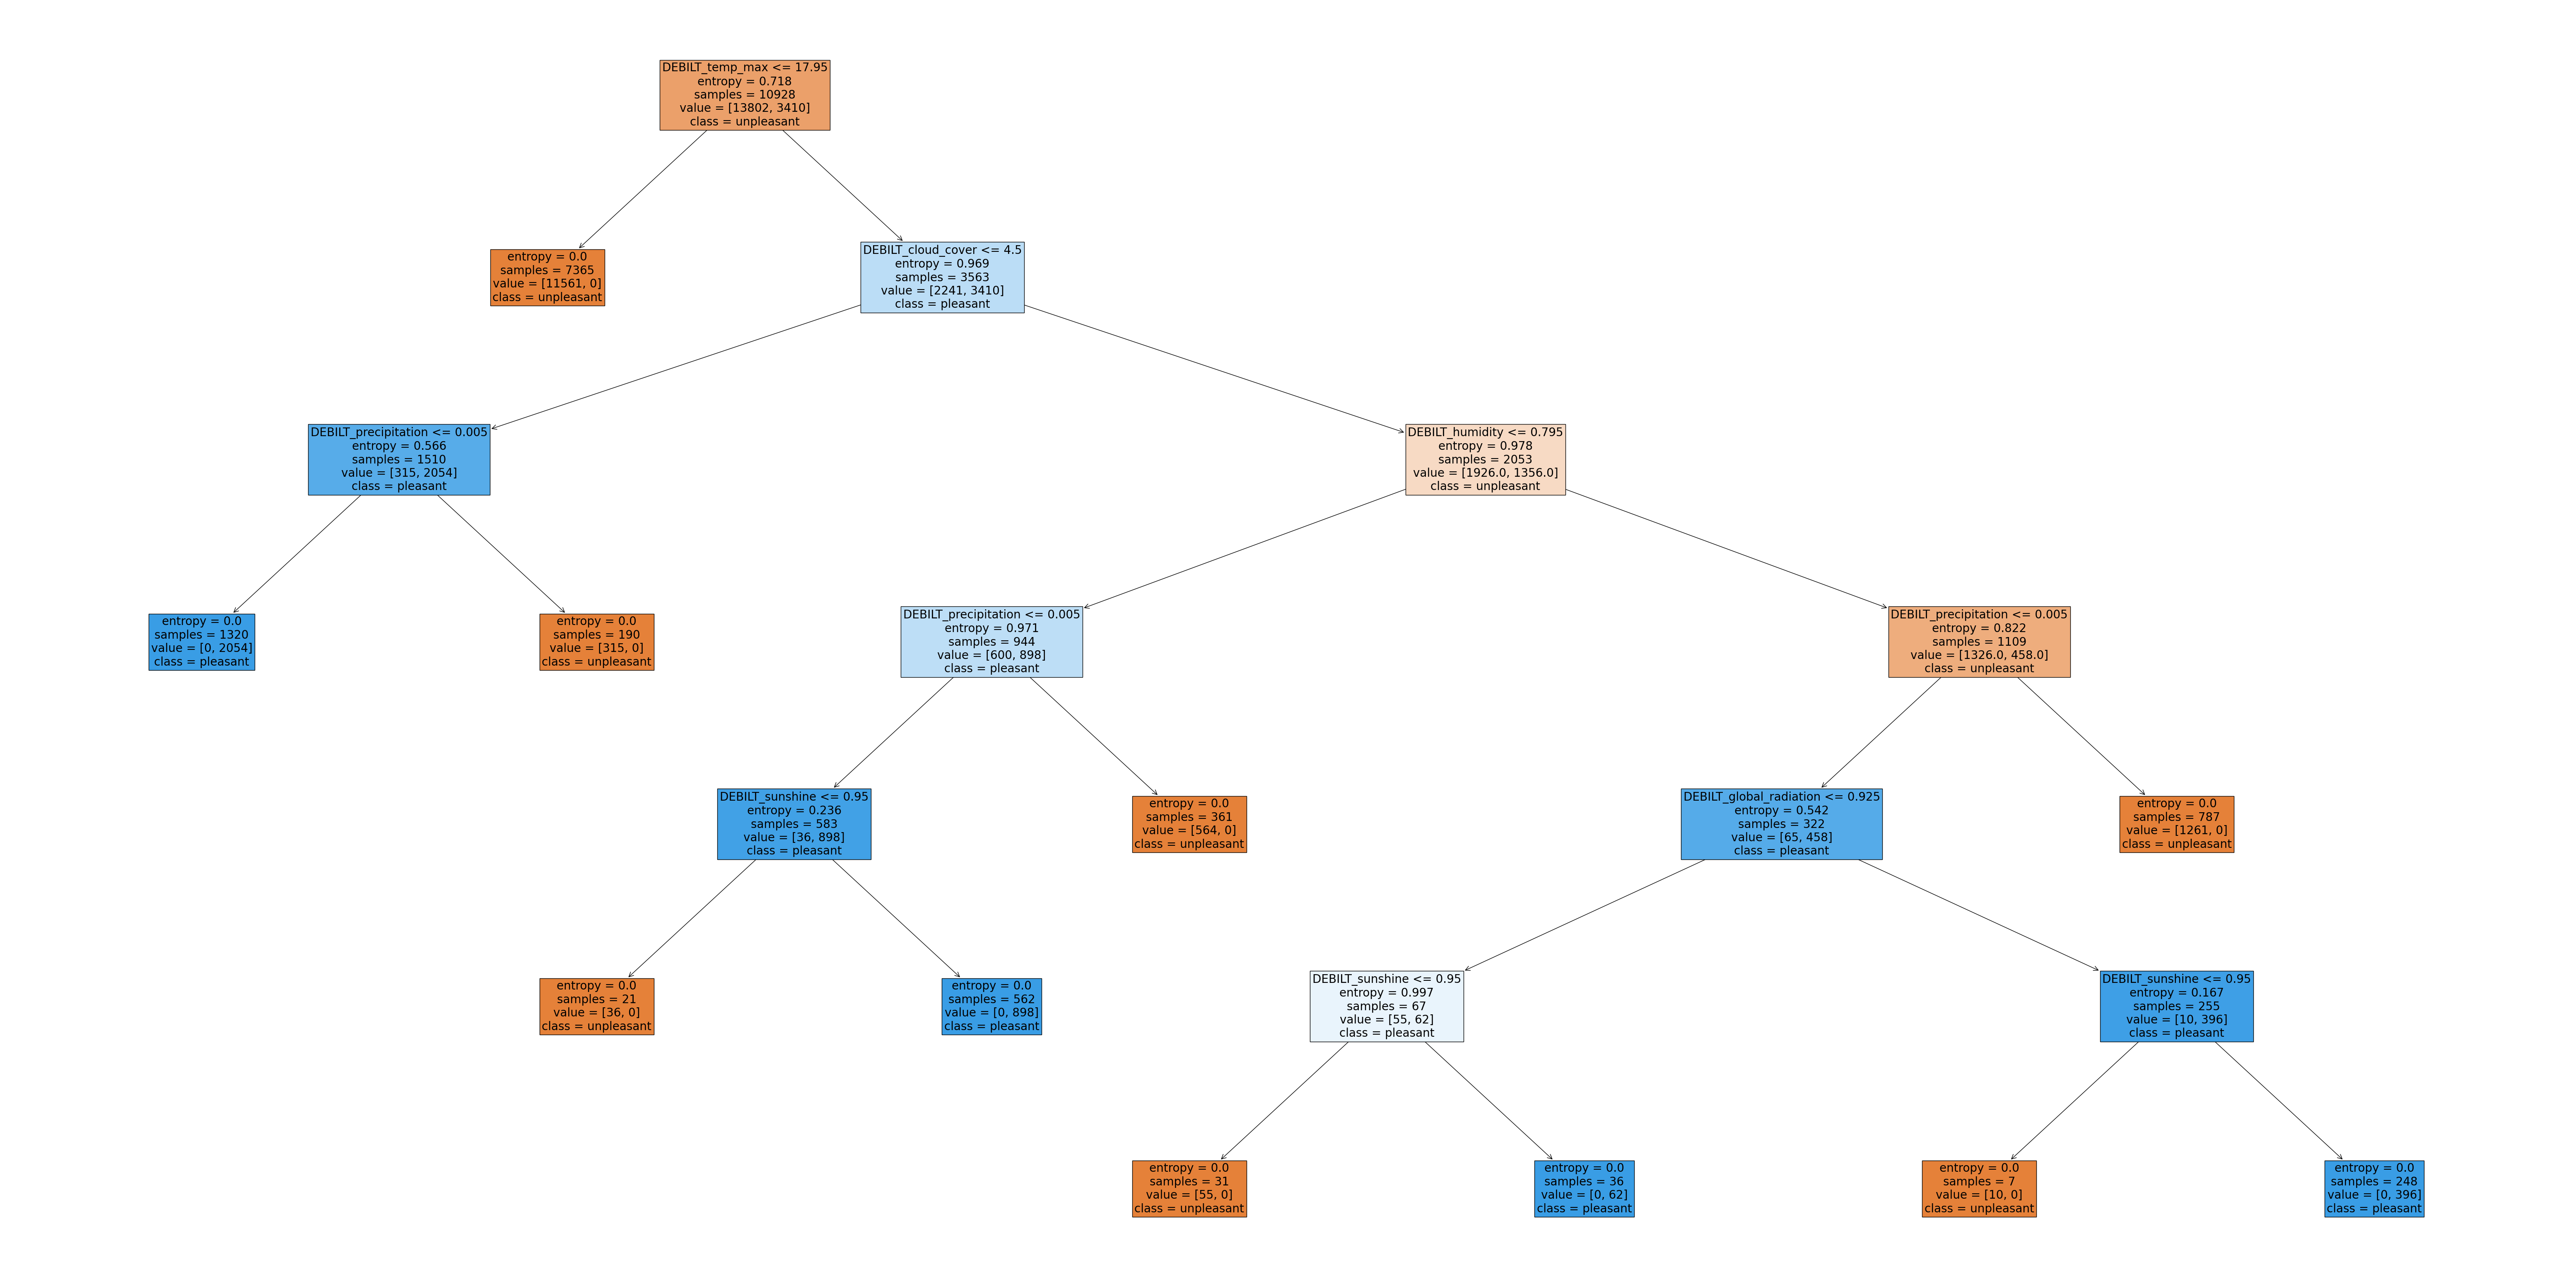

In [86]:
# Plotting a tree from the selected random forest

fig = plt.figure(figsize=(80,40))
plot_tree(clf3.estimators_[6], fontsize = 20, feature_names = df_debilt.columns, class_names=['unpleasant', 'pleasant'], filled=True);

# 7. Feature Importances

In [89]:
# Retrieving the feature importances from the trained model

feature_importances_1 = clf3.feature_importances_
print(clf3.feature_importances_.shape)
feature_importances_1

(9,)


array([0.01822823, 0.00096591, 0.00262977, 0.01560183, 0.35421522,
       0.05664475, 0.11435111, 0.00374423, 0.43361895])

In [91]:
# Creating a list of weather features

weather_list = [feature.replace('DEBILT_', '') for feature in debilt_list]
weather_list

['cloud_cover',
 'humidity',
 'pressure',
 'global_radiation',
 'precipitation',
 'sunshine',
 'temp_mean',
 'temp_min',
 'temp_max']

In [99]:
importance = pd.Series(feature_importances_1, index = weather_list)
importance = importance.sort_values(ascending = False)
importance

temp_max            0.433619
precipitation       0.354215
temp_mean           0.114351
sunshine            0.056645
cloud_cover         0.018228
global_radiation    0.015602
temp_min            0.003744
pressure            0.002630
humidity            0.000966
dtype: float64

In [105]:
# Creating a dataframe to associate weather stations with their importances

df_importance = pd.DataFrame({
    'Feature': weather_list,
    'Importances': feature_importances_1
})

df_importance = df_importance.sort_values(by='Importances', ascending = False)

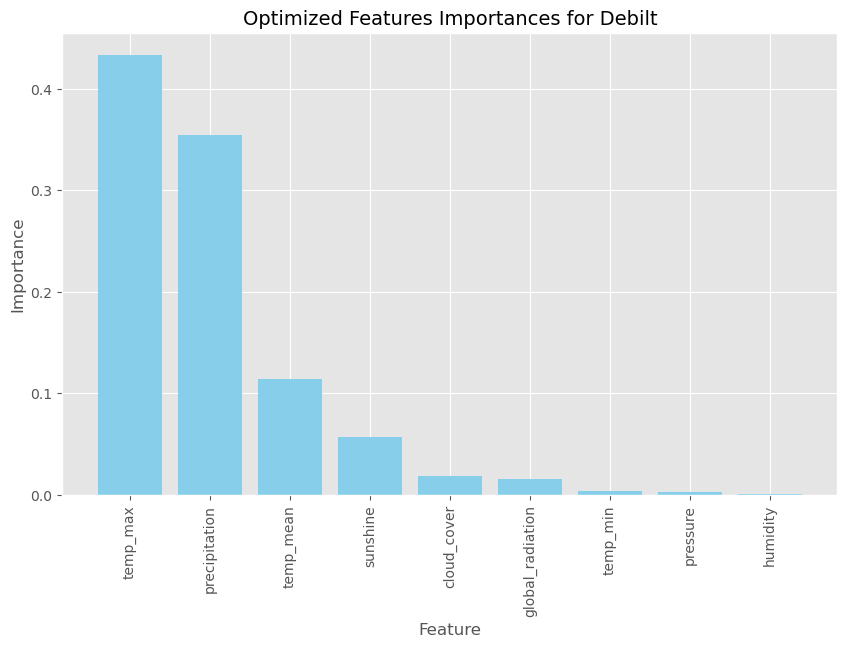

In [113]:
# Plotting the results

%matplotlib inline

plt.style.use('ggplot')
plt.figure(figsize=(10, 6))
plt.bar(df_importance['Feature'], df_importance['Importances'], orientation = 'vertical', color='skyblue')
plt.xticks(weather_list, rotation='vertical')
plt.xlabel('Feature', fontsize=12)
plt.ylabel('Importance', fontsize=12)
plt.title('Optimized Features Importances for Debilt', fontsize=14);

plt.show()